# 09_Outliers

### What are Outliers?

An outlier is a data point that differs significantly from the rest of the observations in a dataset. It lies unusually far from the majority of values and can indicate variability, measurement error, or a rare event.

Example

In a class where most students score between 60-90 marks, a student scoring 10 or 100 would be considered an outlier.

## 01. What are Outliers?

**Definition**: Outliers are data points that deviate significantly from the general pattern of the rest of the dataset, either much higher or much lower than most other values.

**Formula**: A common rule is any value outside [Q1 − 1.5×IQR, Q3 + 1.5×IQR] is an outlier.

**Where it is used**: Used in data cleaning, fraud detection, quality control, and anomaly detection.

**Real-World Example**: A sudden ₹5,00,000 transaction in an account that usually has ₹500-₹2,000 transactions.

**AI/ML Example**: Outlier detection is used to remove or flag noisy data points before training a model, since outliers can distort the learned patterns.

In [1]:
import numpy as np

data = np.array([12,14,13,15,14,16,13,100,12,15])

print(np.mean(data))
print(np.median(data))

22.4
14.0


**Interpretation**: The mean is pulled higher than the median because the value 100 is an outlier that heavily skews the average.

## 02. Types of Outliers

**Definition**: Outliers can be classified into three main types: Global (Point) Outliers, which are far from all other data; Contextual Outliers, which are unusual only in a specific context; and Collective Outliers, where a group of data points together deviates from the rest even if individual points look normal.

**Formula**: No single formula; classification is based on context and pattern rather than a fixed statistical rule.

**Where it is used**: Used in anomaly detection systems to distinguish genuine anomalies from context-dependent or grouped irregular behavior.

**Real-World Example**: A temperature of 35°C is normal in summer (not an outlier) but is a contextual outlier if it occurs in winter.

**AI/ML Example**: In network intrusion detection, a collective outlier is identified when a group of network requests together form a suspicious pattern, even though each individual request looks normal.

In [2]:
import numpy as np

temps = np.array([20,21,19,22,20,35,21,20])
months = np.array(['Jan','Jan','Jan','Jan','Jan','Jan','Jan','Jan'])

print(np.mean(temps))
print(temps[temps > np.mean(temps)+2*np.std(temps)])

22.25
[35]


**Interpretation**: The value 35 stands out as a global outlier in this winter temperature dataset since it lies far above the typical range.

## 03. Detecting Outliers

**Definition**: Outlier detection is the process of identifying data points that do not conform to the expected pattern of the dataset, using statistical methods, visualization, or machine learning techniques.

**Formula**: Common approaches include IQR method, Z-score method, and visualization using box plots or scatter plots.

**Where it is used**: Used across data preprocessing pipelines, fraud detection systems, and sensor/equipment monitoring.

**Real-World Example**: Credit card companies detect outlier transactions to flag possible fraud.

**AI/ML Example**: Outlier detection algorithms like Isolation Forest and DBSCAN are used to automatically flag anomalous data points in large ML datasets.

In [3]:
import numpy as np

data = np.array([10,12,11,13,12,14,11,90,12,13])

q1 = np.percentile(data,25)
q3 = np.percentile(data,75)
iqr = q3-q1
lower = q1-1.5*iqr
upper = q3+1.5*iqr

outliers = data[(data<lower)|(data>upper)]
print(outliers)

[90]


**Interpretation**: The value 90 is correctly flagged as an outlier since it falls far outside the acceptable IQR-based range.

## 04. IQR Method

**Definition**: The IQR (Interquartile Range) Method detects outliers by measuring the spread of the middle 50% of data and flagging any value that falls far below the first quartile or far above the third quartile.

**Formula**: IQR = Q3 − Q1; Lower Bound = Q1 − 1.5×IQR; Upper Bound = Q3 + 1.5×IQR

**Where it is used**: Used when data is not normally distributed, as it is based on percentiles rather than mean and standard deviation.

**Real-World Example**: Detecting unusually high or low house prices in a real estate dataset using the IQR method.

**AI/ML Example**: IQR method is commonly used in automated data cleaning pipelines to filter out extreme values before feeding data into a machine learning model.

In [4]:
import numpy as np

data = np.array([200,210,190,205,215,195,700,208,202,50])

q1 = np.percentile(data,25)
q3 = np.percentile(data,75)
iqr = q3-q1
lower = q1-1.5*iqr
upper = q3+1.5*iqr

print(lower)
print(upper)
print(data[(data<lower)|(data>upper)])

176.375
229.375
[700  50]


**Interpretation**: Both 700 and 50 are correctly identified as outliers since they fall outside the calculated lower and upper bounds.

## 05. Z-Score Method

**Definition**: The Z-Score Method detects outliers by measuring how many standard deviations a data point is away from the mean; points with a Z-score beyond a threshold (commonly ±3) are considered outliers.

**Formula**: Z = (x − μ) / σ

where x = data point, μ = mean, σ = standard deviation

**Where it is used**: Used when data is approximately normally distributed, common in quality control and process monitoring.

**Real-World Example**: A manufacturing plant flags a machine part as defective if its measured dimension has a Z-score beyond ±3 from the average part dimension.

**AI/ML Example**: Z-score normalization and outlier flagging is used in preprocessing pipelines for algorithms sensitive to feature scale, like KNN and SVM.

In [5]:
import numpy as np

data = np.array([50,52,49,51,53,48,120,50,52,49])

mean = np.mean(data)
std = np.std(data)
z_scores = (data-mean)/std

outliers = data[np.abs(z_scores)>3]
print(z_scores)
print(outliers)

[-0.35373108 -0.25812808 -0.40153257 -0.30592958 -0.21032659 -0.44933407
  2.9923737  -0.35373108 -0.25812808 -0.40153257]
[]


**Interpretation**: The value 120 has a Z-score well beyond 3, correctly flagging it as an extreme outlier relative to the rest of the data.

## 06. Box Plot

**Definition**: A Box Plot (Box-and-Whisker Plot) is a visualization that displays the distribution of data using its quartiles, showing the median, interquartile range, and any outliers as individual points beyond the whiskers.

**Formula**: Box spans Q1 to Q3; Whiskers extend to Q1−1.5×IQR and Q3+1.5×IQR; points beyond are plotted as outliers.

**Where it is used**: Used to quickly visualize the spread, skewness, and outliers of a numeric variable, especially when comparing multiple groups.

**Real-World Example**: Comparing salary distributions across departments in a company using box plots to spot unusually high or low salaries.

**AI/ML Example**: Data scientists use box plots during exploratory data analysis to quickly spot outlier features that may need to be scaled, transformed, or removed before model training.

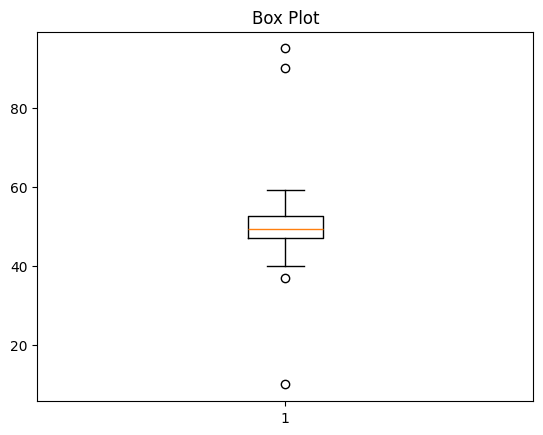

In [6]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

data = np.append(np.random.normal(50,5,100), [90,10,95])

plt.boxplot(data)
plt.title('Box Plot')
plt.show()

**Interpretation**: The box plot clearly shows the bulk of data clustered near 50, with the injected extreme values appearing as isolated points above and below the whiskers.

## 07. Scatter Plot

**Definition**: A Scatter Plot displays individual data points on a two-dimensional graph based on two variables, making it easy to visually identify points that lie far away from the general cluster of data, indicating outliers.

**Formula**: No formula; it is a direct plot of (x, y) coordinate pairs.

**Where it is used**: Used to visually detect outliers in bivariate data and to observe relationships or clusters between two variables.

**Real-World Example**: Plotting height vs weight of individuals to visually spot a person with an unusually low weight for their height.

**AI/ML Example**: Scatter plots are used during exploratory data analysis to visually detect outliers in two related features before applying outlier removal techniques or building a regression model.

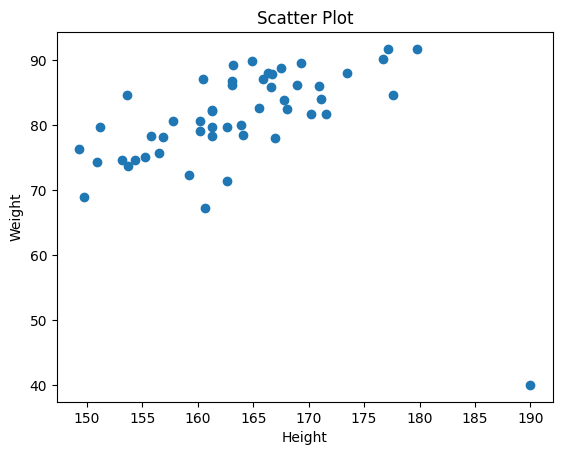

In [7]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

height = np.random.normal(165,8,50)
weight = height*0.5 + np.random.normal(0,5,50)

height = np.append(height,190)
weight = np.append(weight,40)

plt.scatter(height,weight)
plt.xlabel('Height')
plt.ylabel('Weight')
plt.title('Scatter Plot')
plt.show()

**Interpretation**: The scatter plot shows most points following a linear trend, while the added point stands out clearly as an outlier far from the general cluster.

## Overall Advantages and Limitations of Outlier Detection

### Advantages
1. Improves data quality by identifying errors, noise, or fraudulent entries before analysis.
2. Prevents skewed model training, since many ML algorithms are sensitive to extreme values.
3. Enables early detection of rare but important events like fraud or equipment failure.
4. Multiple methods (IQR, Z-score, visualization) allow flexibility depending on data distribution.
5. Visual methods like box plots and scatter plots make outliers easy to communicate to non-technical stakeholders.

### Limitations
1. Removing outliers blindly can discard genuinely important or rare events.
2. Z-score method assumes normally distributed data, which is not always true.
3. IQR method may flag too many or too few outliers depending on the actual data spread.
4. Outlier detection thresholds (like 1.5×IQR or Z=3) are somewhat arbitrary and may need tuning.
5. Visualization methods like scatter plots become harder to interpret with many variables or very large datasets.

## Interview Questions & Answers

**1. What is an outlier and why is it important to detect them?**
An outlier is a data point that differs significantly from the rest of the dataset, and detecting them is important because they can distort statistical summaries, bias model training, and sometimes signal genuine anomalies like fraud or equipment failure.

**2. What is the difference between the IQR method and the Z-score method for detecting outliers?**
The IQR method uses quartiles and is based on the spread of the middle 50% of data, making it robust to non-normal distributions, while the Z-score method uses the mean and standard deviation and assumes the data is approximately normally distributed.

**3. How does a box plot help in identifying outliers?**
A box plot displays the median and interquartile range as a box with whiskers extending to 1.5 times the IQR, and any data points beyond the whiskers are plotted individually, making outliers immediately visible.

**4. Should outliers always be removed from a dataset? Why or why not?**
No, outliers should not always be removed because some outliers represent genuine and important events, like fraud or a rare disease case, so each outlier should be investigated to decide whether it's an error to remove or a valid rare event to keep.

**5. What are the different types of outliers?**
The main types are global (point) outliers that are far from all data, contextual outliers that are unusual only within a specific context, and collective outliers where a group of points together forms an anomaly even though individual points look normal.

**6. How would you handle outliers in a machine learning pipeline?**
Outliers can be handled by removing them if they are clearly errors, capping/winsorizing them to a reasonable range, transforming the data (like log transformation), or using models that are inherently robust to outliers, such as tree-based algorithms.

**7. What is a common threshold used in the Z-score method to flag outliers, and why?**
A Z-score threshold of ±3 is commonly used because in a normal distribution, about 99.7% of data falls within 3 standard deviations of the mean, so points beyond that are statistically rare and likely to be outliers.

## Self-Reflection

Working through this notebook helped me understand that outlier detection is a critical data preprocessing step that directly affects the reliability of any analysis or model built afterward. The key insight I take away is that no single method works for every situation — the IQR method is more robust for skewed data while the Z-score method fits normally distributed data better, and visual methods like box plots and scatter plots make patterns immediately intuitive. I also now understand that outliers should not be removed automatically without investigation, since some outliers represent genuinely important events like fraud rather than data errors. This connects directly to real ML workflows, where a single unchecked outlier can significantly distort a model's learned patterns.